![Banner](https://i.imgur.com/a3uAqnb.png)

# Cell Classification using ViT + Swin Transformers (Sliding-Window Approach)

In this homework, we will classify biomedical cell images using two Vision Transformer architectures:
- **ViT-B/16**
- **Swin-T**

The images have sizes 700*500. Both backbones require inputs of size **224×224**, which is smaller than the actual image sizes. Instead of resizing (which may distort the cell structure), we adopt a **sliding-window** approach:
- **Training**: we randomly crop 224×224 windows
- **Validation**: we center crop 224×224
- **Inference**: we slide a window over the full image and average the probabilities across windows to classify the full image.

Sliding window apporach is very useful if we have huge images sizes, or if we have different resolutions across the images.

In [ ]:
import os
import pandas as pd
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammad2012191/cells-types")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cells-types' dataset.
Path to dataset files: /kaggle/input/cells-types


## 1️⃣ Load Data & Prepare Splits

**Task**: Load the `data.csv` file, extract labels, and perform stratified train/val split.

**ToDo**:
- Read the CSV file and cast `cell_type` to string
- Extract class names and build `label2idx` dictionary
- Perform stratified split with `train_test_split`


In [ ]:
# TODO: Load the CSV file and cast 'cell_type' column to string
# note that: csv file is in dir: /kaggle/input/cells-types/data.csv
df = pd.read_csv(os.path.join(path, 'data.csv'))
df['cell_type'] = df['cell_type'].astype(str)

# TODO: Extract all unique classes and build a label2idx dictionary
# Sort class_names for consistent index mapping
class_names = sorted(df['cell_type'].unique().tolist())
label2idx = {name: idx for idx, name in enumerate(class_names)}

# TODO: Perform stratified train/validation split based on cell_type
"""
documentation available: https://scikit-learn.org/stable/modules/cross_validation.html#stratification
"""
train, val = train_test_split(df, test_size=0.2, stratify=df['cell_type'], random_state=42)

In [ ]:
# for check use:
print(df.head())
print("\nin training set")
print(train.head())
print("\nin validation set")
print(val.head())
print()
print(class_names)
print(label2idx)

   id cell_type
0   0    shsy5y
1   1     astro
2   2      cort
3   3      cort
4   4      cort

in training set
        id cell_type
1326  1326     astro
2251  2251    shsy5y
2524  2524    shsy5y
1124  1124     astro
1189  1189     astro

in validation set
        id cell_type
1272  1272     astro
171    171      cort
537    537    shsy5y
2248  2248    shsy5y
1174  1174     astro

['astro', 'cort', 'shsy5y']
{'astro': 0, 'cort': 1, 'shsy5y': 2}


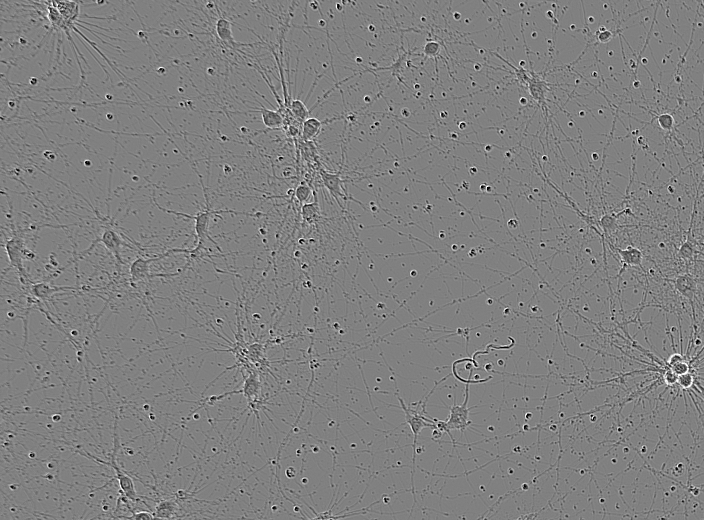

In [ ]:
# Let's look at a sample image
# images are at: /kaggle/input/cells-types/images
image_dir = os.path.join(path, "images")
sample_image_path = os.path.join(image_dir, "2.png")
sample_img = Image.open(sample_image_path)
display(sample_img)

In [ ]:
# check the content in the 'images' folder
!ls -la /kaggle/input/cells-types/images

## 2️⃣ Data Preprocessing

**Task**: Define image transformations and implement a custom dataset class.

**ToDo**:
- Don't use Resize
- Apply `RandomCrop(224)` during training
- Apply `CenterCrop(224)` during validation (best we can do, we will apply sliding window for full image in inference)
- Normalize using ImageNet stats
- Load images from the `images/` folder

In [ ]:
# TODO: Define training transforms (RandomCrop(224), RandomHorizontalFlip, Normalize)
train_trans = T.Compose([
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.ToTensor(), # Convert PIL Image to PyTorch Tensor (H, W, C) -> (C, H, W)
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# TODO: Define validation transforms (CenterCrop(224), Normalize)
val_trans = T.Compose([
    T.CenterCrop(224),
    T.ToTensor(), # Convert PIL Image to PyTorch Tensor (H, W, C) -> (C, H, W)
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# TODO: Implement CellDataset class:
#       - Load image using PIL
#       - Apply transforms
#       - Map label string to index using label2idx
#       - Return image and label
class CellDataset(Dataset):
    def __init__(self, data_dir, images_config, label2idx, transform=None):
        """
        Arguments:
          - data_dir (dtype: string): path to the images directory (e.g., '/kaggle/input/cells-types/images')
          - images_config (dtype: pandas.DataFrame): A dataframe of images for some dataset split (train or val).
            2 columns in total: 'id', 'cell_type'
          - label2idx (dtype: dictionary): mapping between label string and integer index.
          - transform: transformation applied

        Note:
          File structure of images:
          /input
            /images
              0.png
              1.png
              ...
            data.csv

        Return:
          image (dtype: tensor), label (dtype: int)
        """
        self.data_dir = data_dir
        self.images_config = images_config
        self.label2idx = label2idx
        self.transform = transform

    def __len__(self):
        return len(self.images_config)

    def __getitem__(self, idx: int):
        # Get the image ID for the current index in this split
        img_id = self.images_config['id'].iloc[idx]

        # Construct the full image path
        img_filename = f"{img_id}.png"
        img_path = os.path.join(self.data_dir, img_filename)

        # Load image using PIL
        image = Image.open(img_path).convert('RGB')
        # Apply transforms
        if self.transform:
            image = self.transform(image) # Pass PIL Image directly to transforms

        # get the label:
        label = label2idx[self.images_config['cell_type'].iloc[idx]]
        return image, label

## 3️⃣ Create DataLoaders

**Task**: Load datasets using `DataLoader`.

**ToDo**:
- Use `shuffle=True` for training
- Use `shuffle=False` for validation
- Set batch size and workers
- Define the device

In [ ]:
# define the Hyper-parameters:
EPOCHS = 10
BATCH_SIZE = 16
LEARNING_RATE = 0.0004

# define the save path
SAVE_DIR = "/kaggle/result"

In [ ]:
# TODO: Instantiate CellDataset for training and validation
# Pass the full dataframe (df) and the train_ids/val_ids Series along with label2idx
training_set = CellDataset(os.path.join(path, "images"), train, label2idx, train_trans)
validation_set = CellDataset(os.path.join(path, "images"), val, label2idx, val_trans)

# TODO: Wrap both in DataLoaders (shuffle=True for train, False for val)
train_loader = DataLoader(training_set, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_set, batch_size=BATCH_SIZE, shuffle=False)

# TODO: Check device availability and print
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 4️⃣ Build ViT + Swin Combined Model

**Task**: Create a model that extracts features from both backbones and concatenates them.

**ToDo**:
- Load ViT-B/16 (models.vit_b_16) and Swin-T (models.swin_t) with pretrained weights
- Replace their heads with `nn.Identity` (i.e. remove the classifier heads)
- Concatenate features and pass to a linear layer

In [ ]:
import torch

# TODO: Create VitSwinConcat class that inherits from nn.Module
class VitSwinConcat(nn.Module):
# TODO: In __init__():
#       - Load ViT-B/16 and Swin-T from torchvision (pretrained)
#       - Replace their classification heads with Identity()
#       - Concatenate their outputs (768+768) and use Linear classifier
    def __init__(self, num_classes):
        """
        Arguments:
          - num_classes (dtype: int): number of output classes
          - dropout (dtype: float): dropout rate
        """
        super(VitSwinConcat, self).__init__()

        # load vit b 16
        """
        pretrain model available: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vit_b_16.html
        only IMAGENET1K_V1 and IMAGENET1K_SWAG_LINEAR_V1 support min_size (224, 224)
        """
        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).requires_grad_(False)

        # load swin-T
        """
        pretrain model available: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.swin_t.html
        only IMAGENET1K_V1 available
        """
        self.swin = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1).requires_grad_(False)

        # replace their classification heads
        self.vit.head = nn.Identity()
        self.swin.head = nn.Identity()

        # concatenate their outputs (768 + 768)
        # The error indicates that the actual combined features are 1768, not 1536 (768+768).
        # Update self.feature_dim to match the observed runtime dimension.
        self.feature_dim = 1768

        # classifier:
        self.fc = nn.Linear(self.feature_dim, num_classes).requires_grad_(True)

# TODO: In forward(x):
#       - Get features from both backbones
#       - Concatenate along dim=1
#       - Pass through classifier
    def forward(self, x):
        """
        Argument:
          - x: input image
        """
        features_vit = self.vit(x)
        features_swin = self.swin(x)

        # combine two features together
        """
        documentation available: https://docs.pytorch.org/docs/2.13/generated/torch.cat.html
        example: x = torch.randn(2, 3)
        x
        >>> output:
            tensor([[ 0.6580, -1.0969, -0.4614],
            [-0.1034, -0.5790,  0.1497]])
        torch.cat((x, x, x), 0)
        >>> output:
            tensor([[ 0.6580, -1.0969, -0.4614],
            [-0.1034, -0.5790,  0.1497],
            [ 0.6580, -1.0969, -0.4614],
            [-0.1034, -0.5790,  0.1497],
            [ 0.6580, -1.0969, -0.4614],
            [-0.1034, -0.5790,  0.1497]])
        torch.cat((x, x, x), 1)
        >>> output:
            tensor([[ 0.6580, -1.0969, -0.4614,  0.6580, -1.0969, -0.4614,  0.6580,
            -1.0969, -0.4614],
            [-0.1034, -0.5790,  0.1497, -0.1034, -0.5790,  0.1497, -0.1034,
            -0.5790,  0.1497]])
        """
        # Why we do concatenate instead of adding?
        # 1. Adding would lose information
        # 2. their deminsion may not meet
        # 3. They may have different magnitude
        combined_features = torch.cat((features_vit, features_swin), dim=1)

        # pass combined features through classifier
        result = self.fc(combined_features)
        return result

# TODO: Instantiate the model, define CrossEntropy loss and Adam optimizer
model = VitSwinConcat(3)
model = model.to(device)

# define the loss:
criterion = nn.CrossEntropyLoss()

# optimizer setting
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 188MB/s]


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 193MB/s] 


## 5️⃣ Train & Validate

**Task**: Train the model and evaluate accuracy on the validation set.

**ToDo**:
- Write training and inference loops
- Track training/validation loss and accuracy
- Save the model at the end

In [ ]:
# TODO: Loop for each epoch:
#       - Training: Zero grad → Forward → Loss → Backward → Step
#       - Track and print average training loss
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Arguments:
      - model: the model we train
      - train_loader: training data
      - criterion: loss function
      - optimizer: the optimizer we use
      - device: 'cpu' or 'cuda'
    Return:
      training loss, accuracy
    """
    # set the model to training mode
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # here 'pbar' is: 'progress bar'
    pbar = tqdm(train_loader, desc='Training')
    for img, label in pbar:
        # move data to target device
        img = img.to(device)
        label = label.to(device)
        # Zero grad
        optimizer.zero_grad()
        # forward
        outputs = model(img)
        # calculate the loss
        loss = criterion(outputs, label)
        # backward
        loss.backward()
        # update weights
        optimizer.step()
        # Track the loss:
        running_loss = loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        # Update progress bar
        pbar.set_postfix({
            'Loss': f'{running_loss/len(pbar):.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    # return the average training loss and the accuracy
    return running_loss / len(train_loader), 100. * correct / total
# TODO: In evaluation:
#       - Disable gradient, forward pass
#       - Calculate average validation loss and accuracy
def validate(model, validation_loader, criterion, device):
    """
    Arguments:
      - model: the model we evaluate
      - validation_loader: validation data
      - criterion: loss function
      - device: 'cpu' or 'cuda'
    Return:
      validation loss, accuracy
    """
    # set the model into evaluation mode
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # disable gradient
        pbar = tqdm(validation_loader, desc='Validation')
        for img, label in pbar:
            img = img.to(device)
            label = label.to(device)
            # forward
            outputs = model(img)
            # calculate the loss
            loss = criterion(outputs, label)
            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += label.size(0)
            correct += (predicted == label).sum().item()
            # Update progress bar
            pbar.set_postfix({
                'Loss': f'{running_loss/len(pbar):.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
    return running_loss / len(validation_loader), 100. * correct / total

# list for storing the history:
train_losses, train_accuracy = [], []
val_losses, val_accuracy = [], []
# set up training loop:
print("Start training...")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 50)
    # train for one epoch
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accuracy.append(train_acc)
    # validation:
    val_loss, val_acc = validate(model, validation_loader, criterion, device)
    val_losses.append(val_loss)
    val_accuracy.append(val_acc)
    # print the average train loss
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# TODO: Save model checkpoint after training
def save_model(model, save_dir=SAVE_DIR):
  """
  Argument:
    - model: the model you want to save
    - save_dir: location
  """
  # make sure the dirctory exist
  # exist_ok=True, if the dirctory exists, no error
  os.makedirs(save_dir, exist_ok=True)
  model_path = os.path.join(save_dir, 'last.pth')
  torch.save(model.state_dict(), model_path)
  print(f"model saved to {model_path}")

save_model(model)
print(f"\nTraining completed!")

Start training...

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/129 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0003, Train Acc: 94.13%
Val Loss: 0.1086, Val Acc: 96.90%

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/129 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0002, Train Acc: 99.18%
Val Loss: 0.0247, Val Acc: 99.03%

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/129 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0012, Train Acc: 99.32%
Val Loss: 0.0239, Val Acc: 99.42%
model saved to /kaggle/result/last.pth

Training completed!


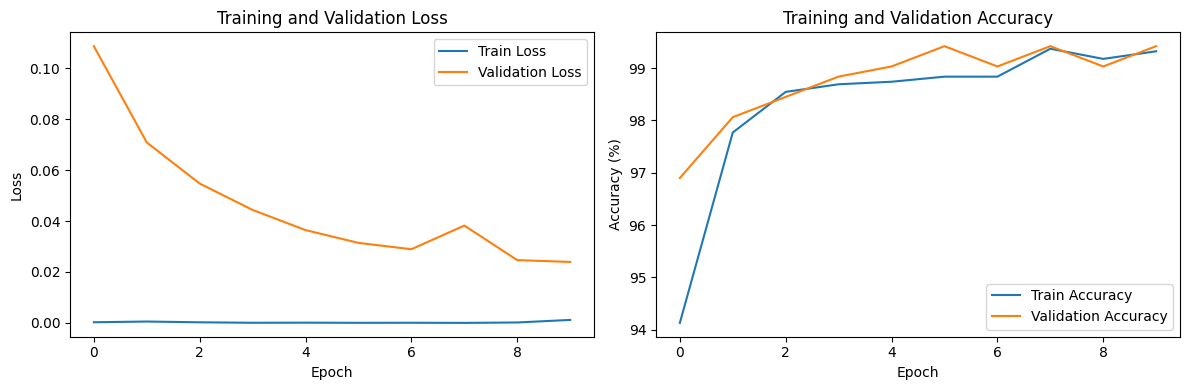

In [ ]:
# Plot the training and validation loss and accuracy curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

## 6️⃣ Sliding-Window Inference

*Task*: Write a function to classify a full image(not the cropped one) using sliding windows.

*ToDo*:
- Slide a 224×224 window with stride (e.g. 112)
- Average softmax probabilities
- Print individual patch predictions and final class

In [ ]:
# TODO: Define inference_sliding_window(model, img_path):
#       - Load full-size image
#       - Slide 224×224 window (stride=112)
#       - For each patch: normalize → predict → store softmax
def inference_sliding_window(model, img_relative_path: str, label2idx: dict):
    """
    Arguments:
      - model: the trained model.
      - img_relative_path: the relative path to the testing image (e.g., "images/5.png").
      - label2idx: The dictionary mapping class names to integer indices.
    """
    # Create an inverse mapping from index to label name
    idx2label = {idx: name for name, idx in label2idx.items()}
    # load the image first
    full_img_path = os.path.join(path, img_relative_path)
    image = Image.open(full_img_path).convert('RGB')
    img_w, img_h = image.size
    # transformation for each patch
    infer_trans = T.Compose([
        T.ToTensor(), # Convert PIL Image to PyTorch Tensor
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # create patches for that image
    patches = []
    for y in range(0, img_h - 224 + 1, 112):
      for x in range(0, img_w - 224 + 1, 112):
        # Crop patch
        patch = image.crop((x, y, x + 224, y + 224))
        # transform to tensor and store it in patches
        patch_tensor = infer_trans(patch)
        patches.append(patch_tensor)

    num_patches = len(patches)

    # start evaluation
    model.eval()
    model = model.to(device)
    probabilities = []
    with torch.no_grad():
        for i in range(num_patches):
            # put each patch into model, and predict
            # Add a batch dimension to the patch tensor for the model input
            p = patches[i].unsqueeze(0).to(device)
            logits = model(p)
            prob = nn.functional.softmax(logits, dim=1)
            # store softmax probabilities
            probabilities.append(prob.cpu().squeeze(0).numpy()) # Remove batch dimension
    # finally, take average and print the prediction
    probabilities = np.array(probabilities)

    # Get class names in the order of their indices
    class_names = ['astro', 'cort', 'shsy5y']
    # Calculate averaged probabilities across patches
    averaged_probs = np.mean(probabilities, axis=0)
    predict_idx = np.argmax(averaged_probs)
    final_class = idx2label[predict_idx]
    # add the average result to the end
    probabilities = np.concatenate((probabilities, np.expand_dims(averaged_probs, axis=0)), axis=0)
    # Create a DataFrame for individual patch predictions
    patch_predictions_df = pd.DataFrame(probabilities, columns=class_names, index=[f'patch_{i}' for i in range(num_patches)].append('Average'))
    display(patch_predictions_df)
    # print the prediction
    print(f"Final predicted class: {final_class}")

# TODO: Average probabilities across patches
# TODO: Print:
#       - Probabilities for each patch
#       - Averaged probabilities
#       - Final predicted class for full image (argmax of average)

# TODO: Call inference_sliding_window(model, "images/5.png") or any other test image
# load the model:
# recreate model architecture first
loaded_model = VitSwinConcat(3)
model_path = os.path.join(SAVE_DIR, 'last.pth')
loaded_model.load_state_dict(torch.load(model_path, map_location=device))
inference_sliding_window(loaded_model, os.path.join("images", "5.png"), label2idx)

# Example output:

# Patch 0:  {'astro': 0.0003629255515988916, 'cort': 0.9995890259742737, 'shsy5y': 4.803628326044418e-05}
# Patch 1:  {'astro': 0.002050854032859206, 'cort': 0.9978287816047668, 'shsy5y': 0.00012039497960358858}
# Patch 2:  {'astro': 0.0003413844096940011, 'cort': 0.9996126294136047, 'shsy5y': 4.605785943567753e-05}
# Patch 3:  {'astro': 0.0004650430055335164, 'cort': 0.9994938373565674, 'shsy5y': 4.10635257139802e-05}
# ...
# Patch 12:  {'astro': 0.00020842120284214616, 'cort': 0.9997585415840149, 'shsy5y': 3.304508572909981e-05}
# Patch 13:  {'astro': 0.0001657304965192452, 'cort': 0.9998027682304382, 'shsy5y': 3.147909228573553e-05}
# Patch 14:  {'astro': 0.0004247387987561524, 'cort': 0.9994537234306335, 'shsy5y': 0.00012151007103966549}
# Average:  {'astro': 0.0005312784924171865, 'cort': 0.9994047284126282, 'shsy5y': 6.39661229797639e-05}
# Final class:  cort

,astro,cort,shsy5y
0,0.000330,0.999556,0.000113
1,0.006081,0.993466,0.000453
2,0.001345,0.998420,0.000235
3,0.000541,0.999425,0.000034
4,0.000254,0.999720,0.000026
5,0.000051,0.999909,0.000040
6,0.000025,0.999968,0.000007
7,0.000035,0.999960,0.000005
8,0.000015,0.999983,0.000003
9,0.000214,0.999778,0.000008


Final predicted class: cort


## 📝 Evaluation Criteria

Your Cell Classification homework will be evaluated based on:

1. **Implementation Correctness (70%)**
   - Proper stratified splitting and label encoding
   - Correct use of ViT-B/16 and Swin-T architectures
   - Model correctly concatenates features from both backbones
   - Sliding-window inference correctly averages predictions

2. **Training and Results (20%)**
   - Model trains and converges on validation set
   - Accuracy and loss values are properly printed each epoch
   - Trained weights saved successfully and reused for inference

3. **Code Quality and Structure (10%)**
   - Code follows modular structure with appropriate class/function design
   - Clean, readable code with `ToDo` comments per cell
   - Results are printed clearly, including per-patch and average inference
